In [ ]:
!pip install category-encoders

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

pd.set_option('display.max_rows', 100)

from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder, OneHotEncoder
from category_encoders import BinaryEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import CategoricalNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

import os

## 1. Data Loading
This section loads the training and testing datasets from CSV files into pandas DataFrames. It also displays the first few rows of the training data to get a quick overview.

In [ ]:
train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')


train.head(5)

,MachineID,ProductName,EngineVersion,AppVersion,SignatureVersion,IsBetaUser,RealTimeProtectionState,IsPassiveModeEnabled,AntivirusConfigID,NumAntivirusProductsInstalled,...,IsSecureBootEnabled,IsVirtualDevice,IsTouchEnabled,IsPenCapable,IsAlwaysOnAlwaysConnectedCapable,IsGamer,RegionIdentifier,DateAS,DateOS,target
0,f541bae429089117c4aac39c90dd3416,win8defender,1.1.15200.1,4.18.1807.18075,1.275.1003.0,0,7.0,0,53447.0,1.0,...,0,0.0,1,0,1.0,0.0,6.0,2018-09-10 10:11:00,2018-04-17,0
1,dc2b14d9ce3a0ce4050bb640190f2ca5,win8defender,1.1.15100.1,4.18.1807.18075,1.273.1465.0,0,7.0,0,53447.0,1.0,...,1,0.0,0,0,0.0,0.0,10.0,2018-08-16 00:01:00,2018-08-14,1
2,fd20c5f010e9c5f91ad1c6b3e0da68a0,win8defender,1.1.15200.1,4.18.1807.18075,1.275.1546.0,0,7.0,0,53447.0,1.0,...,0,0.0,0,0,0.0,1.0,6.0,2018-09-20 23:20:00,2018-09-11,1
3,38711eae85eb77a72ec5dfdf27eb2a76,win8defender,1.1.15200.1,4.12.17007.18011,1.275.1141.0,0,7.0,0,46413.0,2.0,...,1,0.0,0,0,0.0,0.0,12.0,2018-09-14 00:32:00,2018-01-03,1
4,32607c9a543a9214e2c7e45800ed4849,win8defender,1.1.15200.1,4.13.17134.228,1.275.1283.0,0,7.0,0,40466.0,2.0,...,0,0.0,0,0,0.0,1.0,7.0,2018-09-15 19:34:00,2018-09-11,0


## 2. Initial Data Exploration
Here, a custom function `initial_exploration` is defined and used to get a high-level overview of the dataset. This includes:
- The shape of the dataset (number of rows and columns).
- Separation of features (X) and the target variable (y).
- Identification of numerical and categorical features.
- Counting features with missing values (NaNs).

### Detailed Initial Observations

During the initial exploration, we observed that the dataset contains a mix of numerical and categorical features. The presence of a significant number of features with missing values (33 out of 75) immediately signals the need for a robust imputation strategy. Identifying these missing values early on is crucial for subsequent preprocessing steps.

The target variable's distribution is also important; if it's imbalanced, we might need to consider techniques like oversampling, undersampling, or using appropriate evaluation metrics beyond simple accuracy.

In [ ]:
def initial_exploration(dataset):
    print(f"Shape of Dataset: {dataset.shape}")
    feature_matrix = dataset.drop(columns=['target'])
    label_vector = dataset['target']

    numerical_features = feature_matrix.select_dtypes(include='number').columns
    categorical_features = feature_matrix.select_dtypes(include='object').columns
    print(f"Numerical Features: {len(numerical_features)}")
    print(f"Categorical Features: {len(categorical_features)}")

    nan_features = dataset.columns[dataset.isna().sum() > 0]
    print(f"Features with NaN: {len(nan_features)}")
    return feature_matrix, label_vector, numerical_features, categorical_features

X_train, y_train, numerical_features, categorical_features = initial_exploration(train)


Shape of Dataset: (100000, 76)
Numerical Features: 47
Categorical Features: 28
Features with NaN: 33


## 3. Missing Value Analysis
The `null_values_analyze` function provides a detailed look at features containing missing values. It shows the count of `NaN`s and their percentage relative to the total number of rows, which helps in deciding on imputation strategies.

### Missing Value Handling Strategy

The detailed analysis of missing values revealed that several features have a small percentage of NaNs, typically less than 1%. For these features, simple imputation strategies are usually sufficient and less likely to introduce bias. Given the nature of this dataset (security-related, potentially many categorical or pseudo-numerical IDs), imputing with the most frequent value (mode) is a reasonable default for many columns, especially those with low cardinality or where a missing value might imply 'not present' or 'unknown' which the mode can often represent if it's a common state. We will refine this strategy during the preprocessing phase for specific column types.

In [ ]:
def null_values_analyze(dataset):
    custom_df = dataset.isna().sum()
    custom_df = custom_df[custom_df > 0].to_frame(name='NaN Count')
    custom_df['NaN %'] = (custom_df['NaN Count'] / dataset.shape[0]) * 100

    print(custom_df)

null_values_analyze(train)


                                    NaN Count  NaN %
RealTimeProtectionState                    66  0.066
AntivirusConfigID                          76  0.076
NumAntivirusProductsInstalled              76  0.076
NumAntivirusProductsEnabled                76  0.076
CityID                                    623  0.623
IsSystemProtected                          76  0.076
SMode                                     981  0.981
IEVersionID                               107  0.107
FirewallEnabled                           166  0.166
EnableLUA                                  19  0.019
OEMNameID                                 212  0.212
OEMModelID                                228  0.228
ProcessorCoreCount                         85  0.085
ProcessorManufacturerID                    85  0.085
ProcessorModelID                           85  0.085
PrimaryDiskCapacityMB                     110  0.110
PrimaryDiskType                            23  0.023
SystemVolumeCapacityMB                    110 

## 4. Numerical Feature Analysis
This section focuses on understanding the distribution and characteristics of numerical features. It includes:
- Descriptive statistics using `describe()`.
- Box plots to visualize the spread and identify outliers.
- Histograms to show the distribution shapes.
- A correlation heatmap to illustrate relationships between numerical features.

### Insights from Numerical Feature Analysis

The descriptive statistics, box plots, and histograms for numerical features provide valuable insights. Some features, like `IsBetaUser` or `IsPassiveModeEnabled`, appear to be binary flags disguised as numerical types, with `describe()` showing `0` and `1` as min/max and very low standard deviation. This confirms they should be treated as categorical during encoding.

Box plots help identify potential outliers that might need special handling or robust scaling methods. Histograms show various distributions, from heavily skewed to more uniform, guiding the choice of transformations (e.g., log transformation for highly skewed features, though not explicitly applied here for simplicity). The correlation heatmap helps identify highly correlated numerical features, which could lead to multicollinearity if not addressed. However, for tree-based models like LGBM or XGBoost, multicollinearity is less of a concern than for linear models.

In [ ]:
X_train[numerical_features].describe()


,IsBetaUser,RealTimeProtectionState,IsPassiveModeEnabled,AntivirusConfigID,NumAntivirusProductsInstalled,NumAntivirusProductsEnabled,HasTpm,CountryID,CityID,GeoRegionID,...,IsFlightsDisabled,FirmwareManufacturerID,FirmwareVersionID,IsSecureBootEnabled,IsVirtualDevice,IsTouchEnabled,IsPenCapable,IsAlwaysOnAlwaysConnectedCapable,IsGamer,RegionIdentifier
count,100000.0,99934.000000,100000.000000,99924.000000,99924.000000,99924.000000,100000.000000,100000.000000,99377.000000,100000.000000,...,99674.0,99624.000000,99666.000000,100000.000000,99980.000000,100000.000000,100000.000000,99866.000000,99441.000000,99441.000000
mean,0.0,6.848430,0.017620,47975.710440,1.326528,1.018264,0.996780,108.078790,81029.938587,169.741630,...,0.0,401.987613,32942.648044,0.495690,0.003841,0.128470,0.040580,0.058398,0.296668,7.875866
std,0.0,1.015166,0.131566,13803.321533,0.520681,0.155291,0.056654,63.062151,48944.027074,89.188929,...,0.0,221.318891,21151.970827,0.499984,0.061855,0.334614,0.197316,0.234496,0.456791,4.562533
min,0.0,0.000000,0.000000,39.000000,1.000000,0.000000,0.000000,1.000000,7.000000,1.000000,...,0.0,2.000000,121.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.0,7.000000,0.000000,49480.000000,1.000000,1.000000,1.000000,51.000000,36694.000000,89.000000,...,0.0,142.000000,13020.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
50%,0.0,7.000000,0.000000,53447.000000,1.000000,1.000000,1.000000,97.000000,82373.000000,181.000000,...,0.0,500.000000,33066.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000
75%,0.0,7.000000,0.000000,53447.000000,2.000000,1.000000,1.000000,162.000000,122835.000000,267.000000,...,0.0,556.000000,52357.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,11.000000
max,0.0,8.000000,1.000000,70490.000000,5.000000,4.000000,1.000000,222.000000,167957.000000,296.000000,...,0.0,1083.000000,72091.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,15.000000


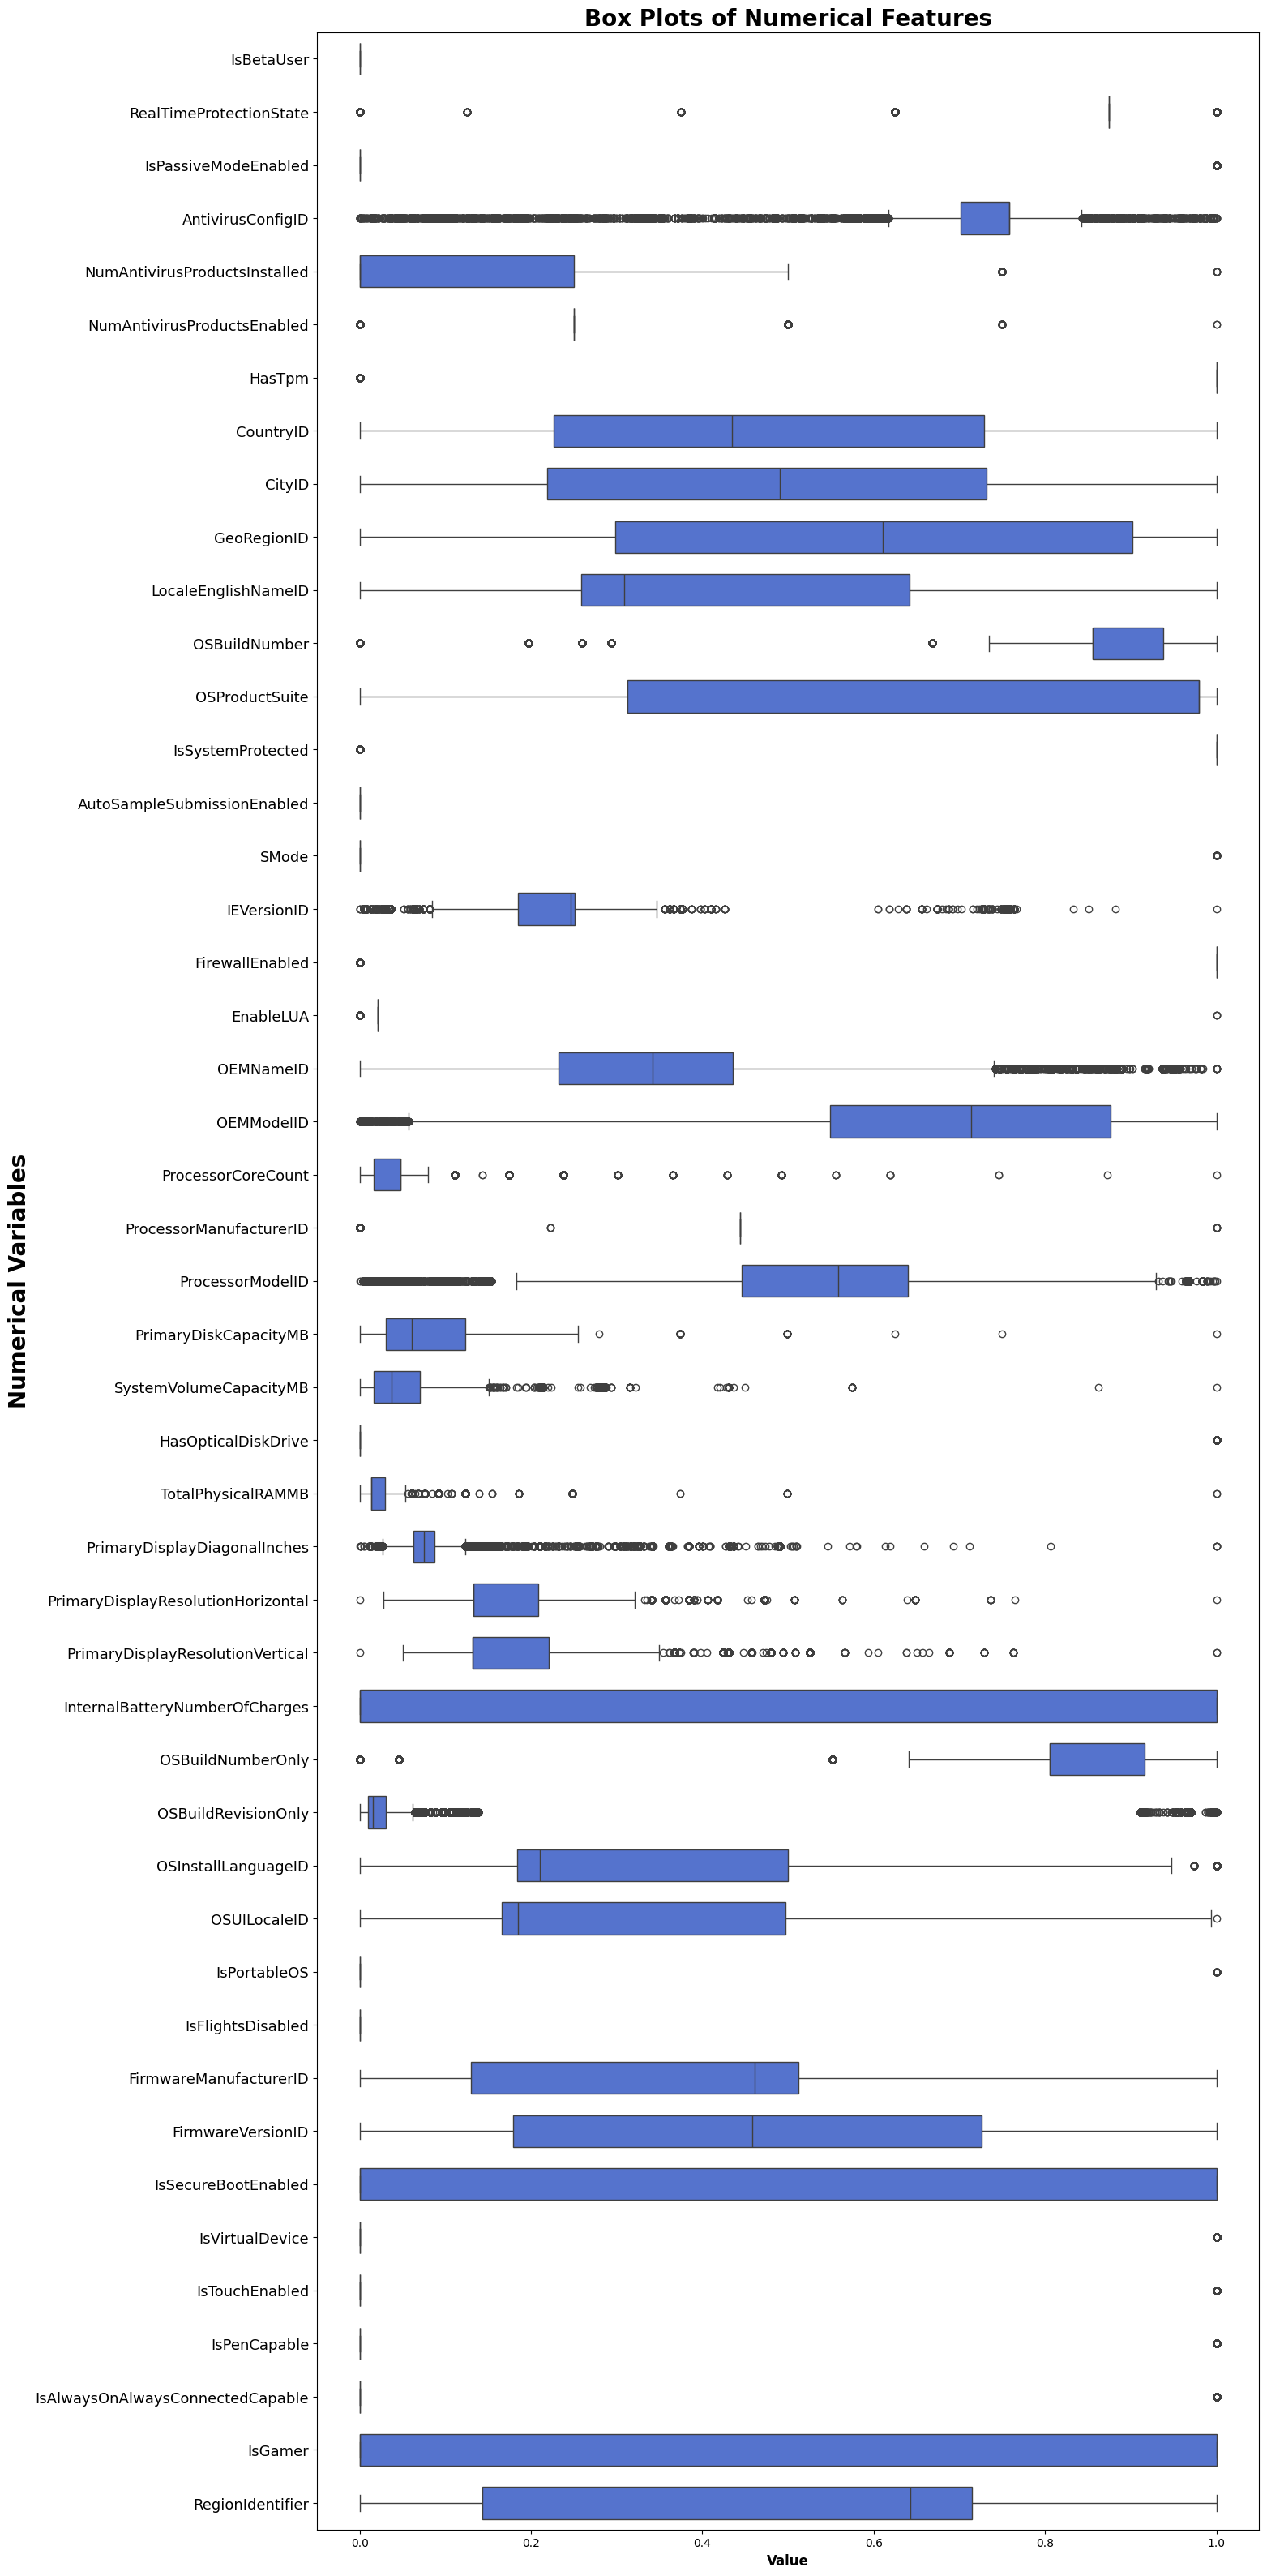

In [ ]:
plt.figure(figsize=(15, 40))

sns.boxplot(data=MinMaxScaler().fit_transform(train[numerical_features]), color="royalblue", orient="h", width=0.6)

plt.title("Box Plots of Numerical Features", fontweight="bold", fontsize=20)
plt.xlabel("Value", fontweight="bold", fontsize=12)
plt.ylabel("Numerical Variables", fontweight="bold", fontsize=20)
plt.yticks(ticks=list(range(len(numerical_features))), labels=numerical_features, fontsize=13)

plt.show()


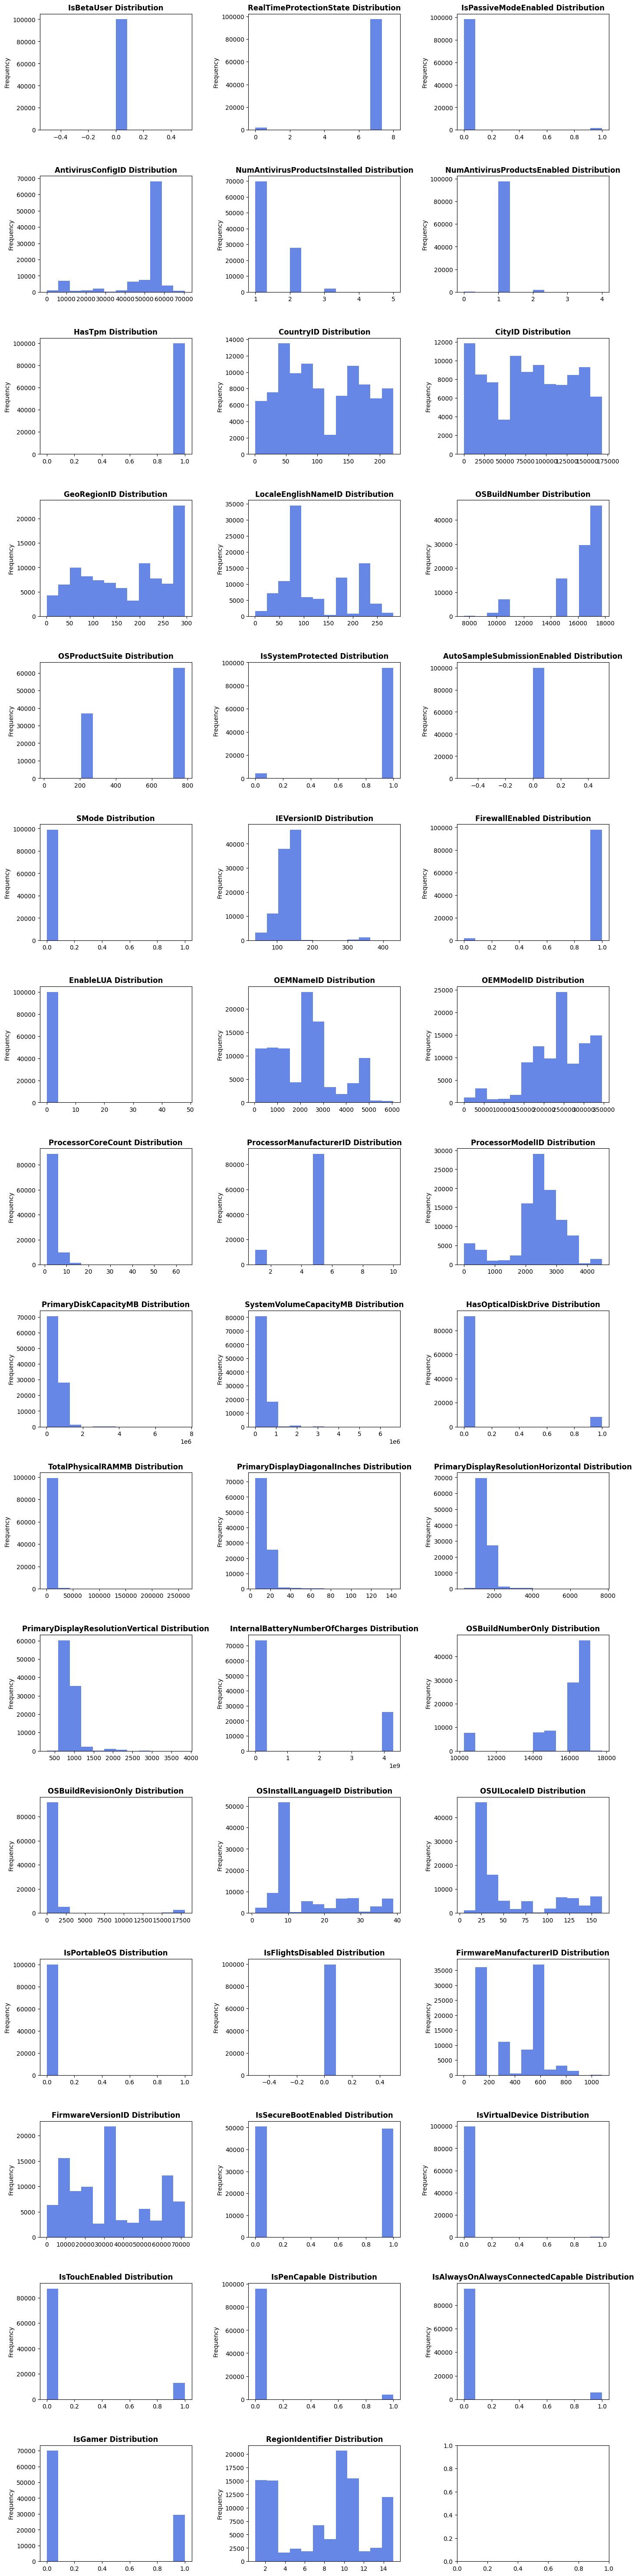

In [ ]:
fig, axes = plt.subplots(16,3, figsize=(15,60))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    X_train[feature].plot(kind="hist", ax=axes[i], bins=12, color='royalblue', alpha=0.8)
    axes[i].set_title(f"{feature} Distribution", fontweight="bold")
    axes[i].set_ylabel("Frequency")

fig.tight_layout(pad=3.0)
plt.show()


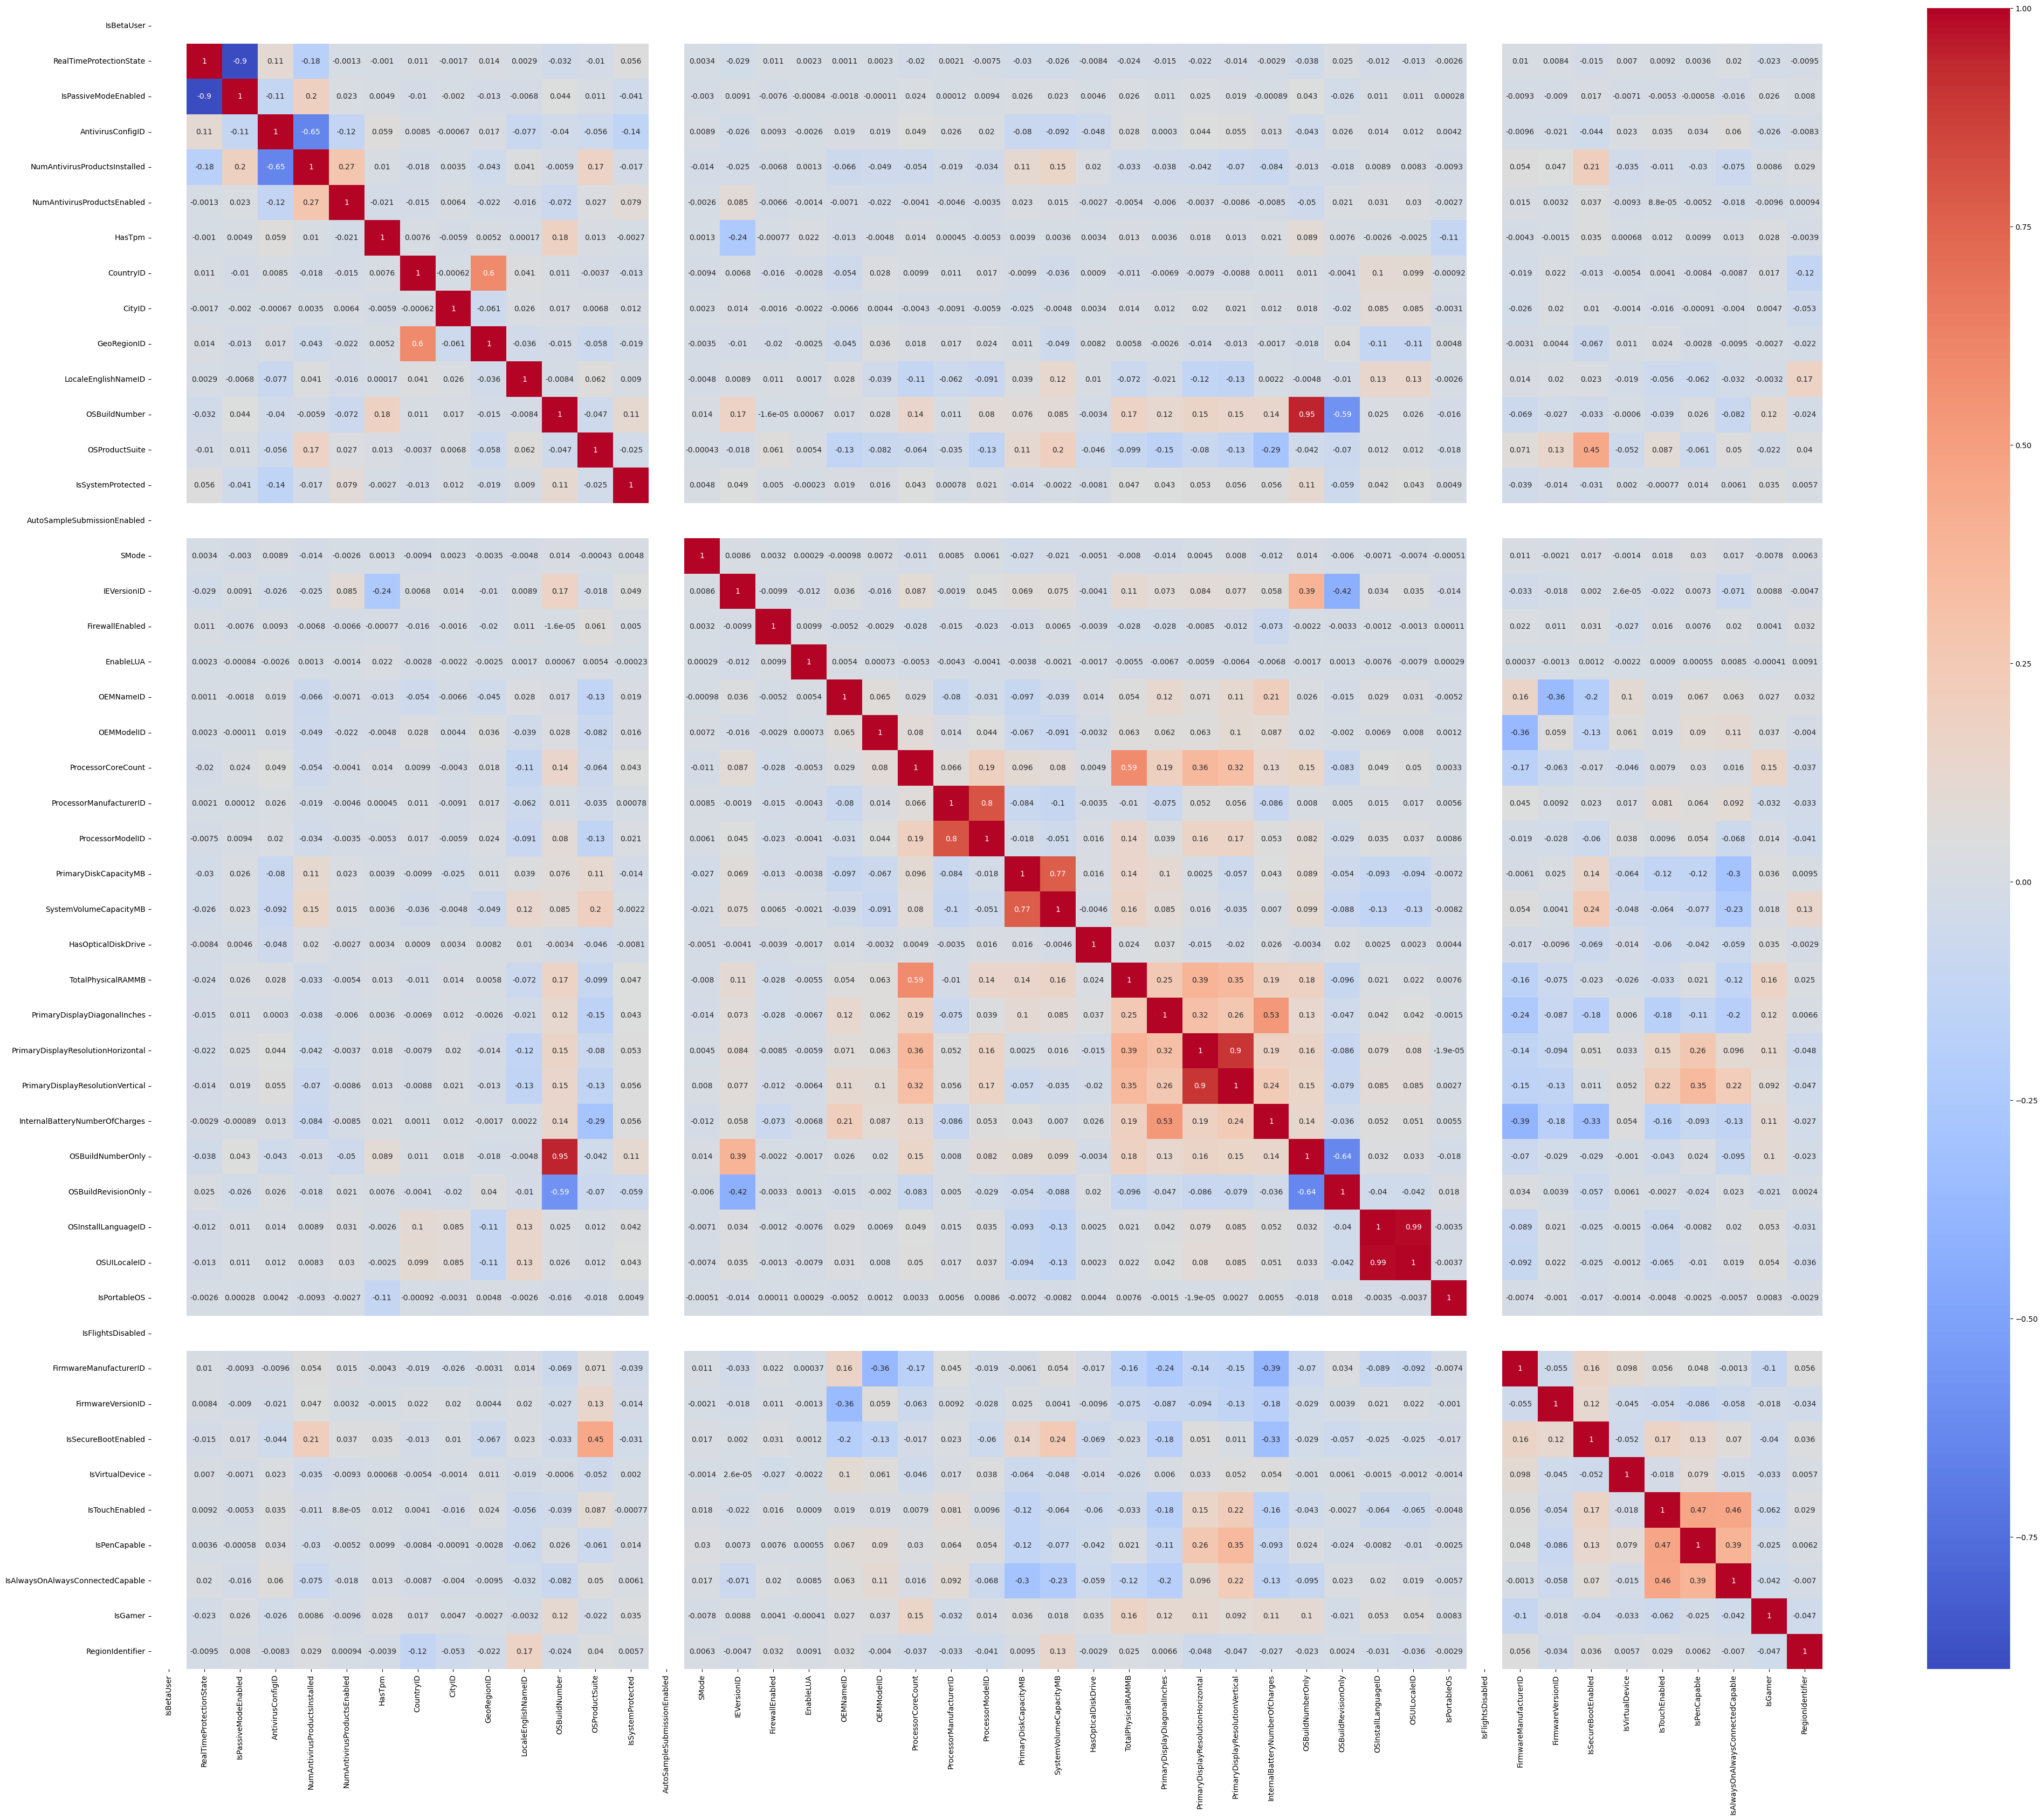

In [ ]:
plt.figure(figsize=(50, 40))
sns.heatmap(X_train[numerical_features].corr(), annot=True, cmap='coolwarm')
plt.show()


## 5. Categorical Feature Analysis
This part of the notebook explores categorical features, focusing on their distributions and inter-relationships.
- Count plots are generated for categorical features with 10 or fewer unique values to visualize their frequency distributions.
- Cramér's V statistic is calculated and visualized with a heatmap to assess the correlation between categorical features.

### Insights from Categorical Feature Analysis

Analyzing categorical features with count plots revealed the distribution of different categories. Many categorical features exhibit a highly skewed distribution, with one or two categories dominating. This is important to note for encoding strategies; one-hot encoding might lead to a very sparse matrix for high-cardinality features, making binary or ordinal encoding more suitable.

Cramér's V heatmap provides a measure of association between categorical variables. High Cramér's V values suggest strong relationships, indicating potential redundancy or hierarchical structures. Understanding these relationships can inform feature engineering (e.g., combining categories or creating interaction terms) or feature selection to avoid including too many highly correlated features, which can sometimes slow down training or make interpretation harder.

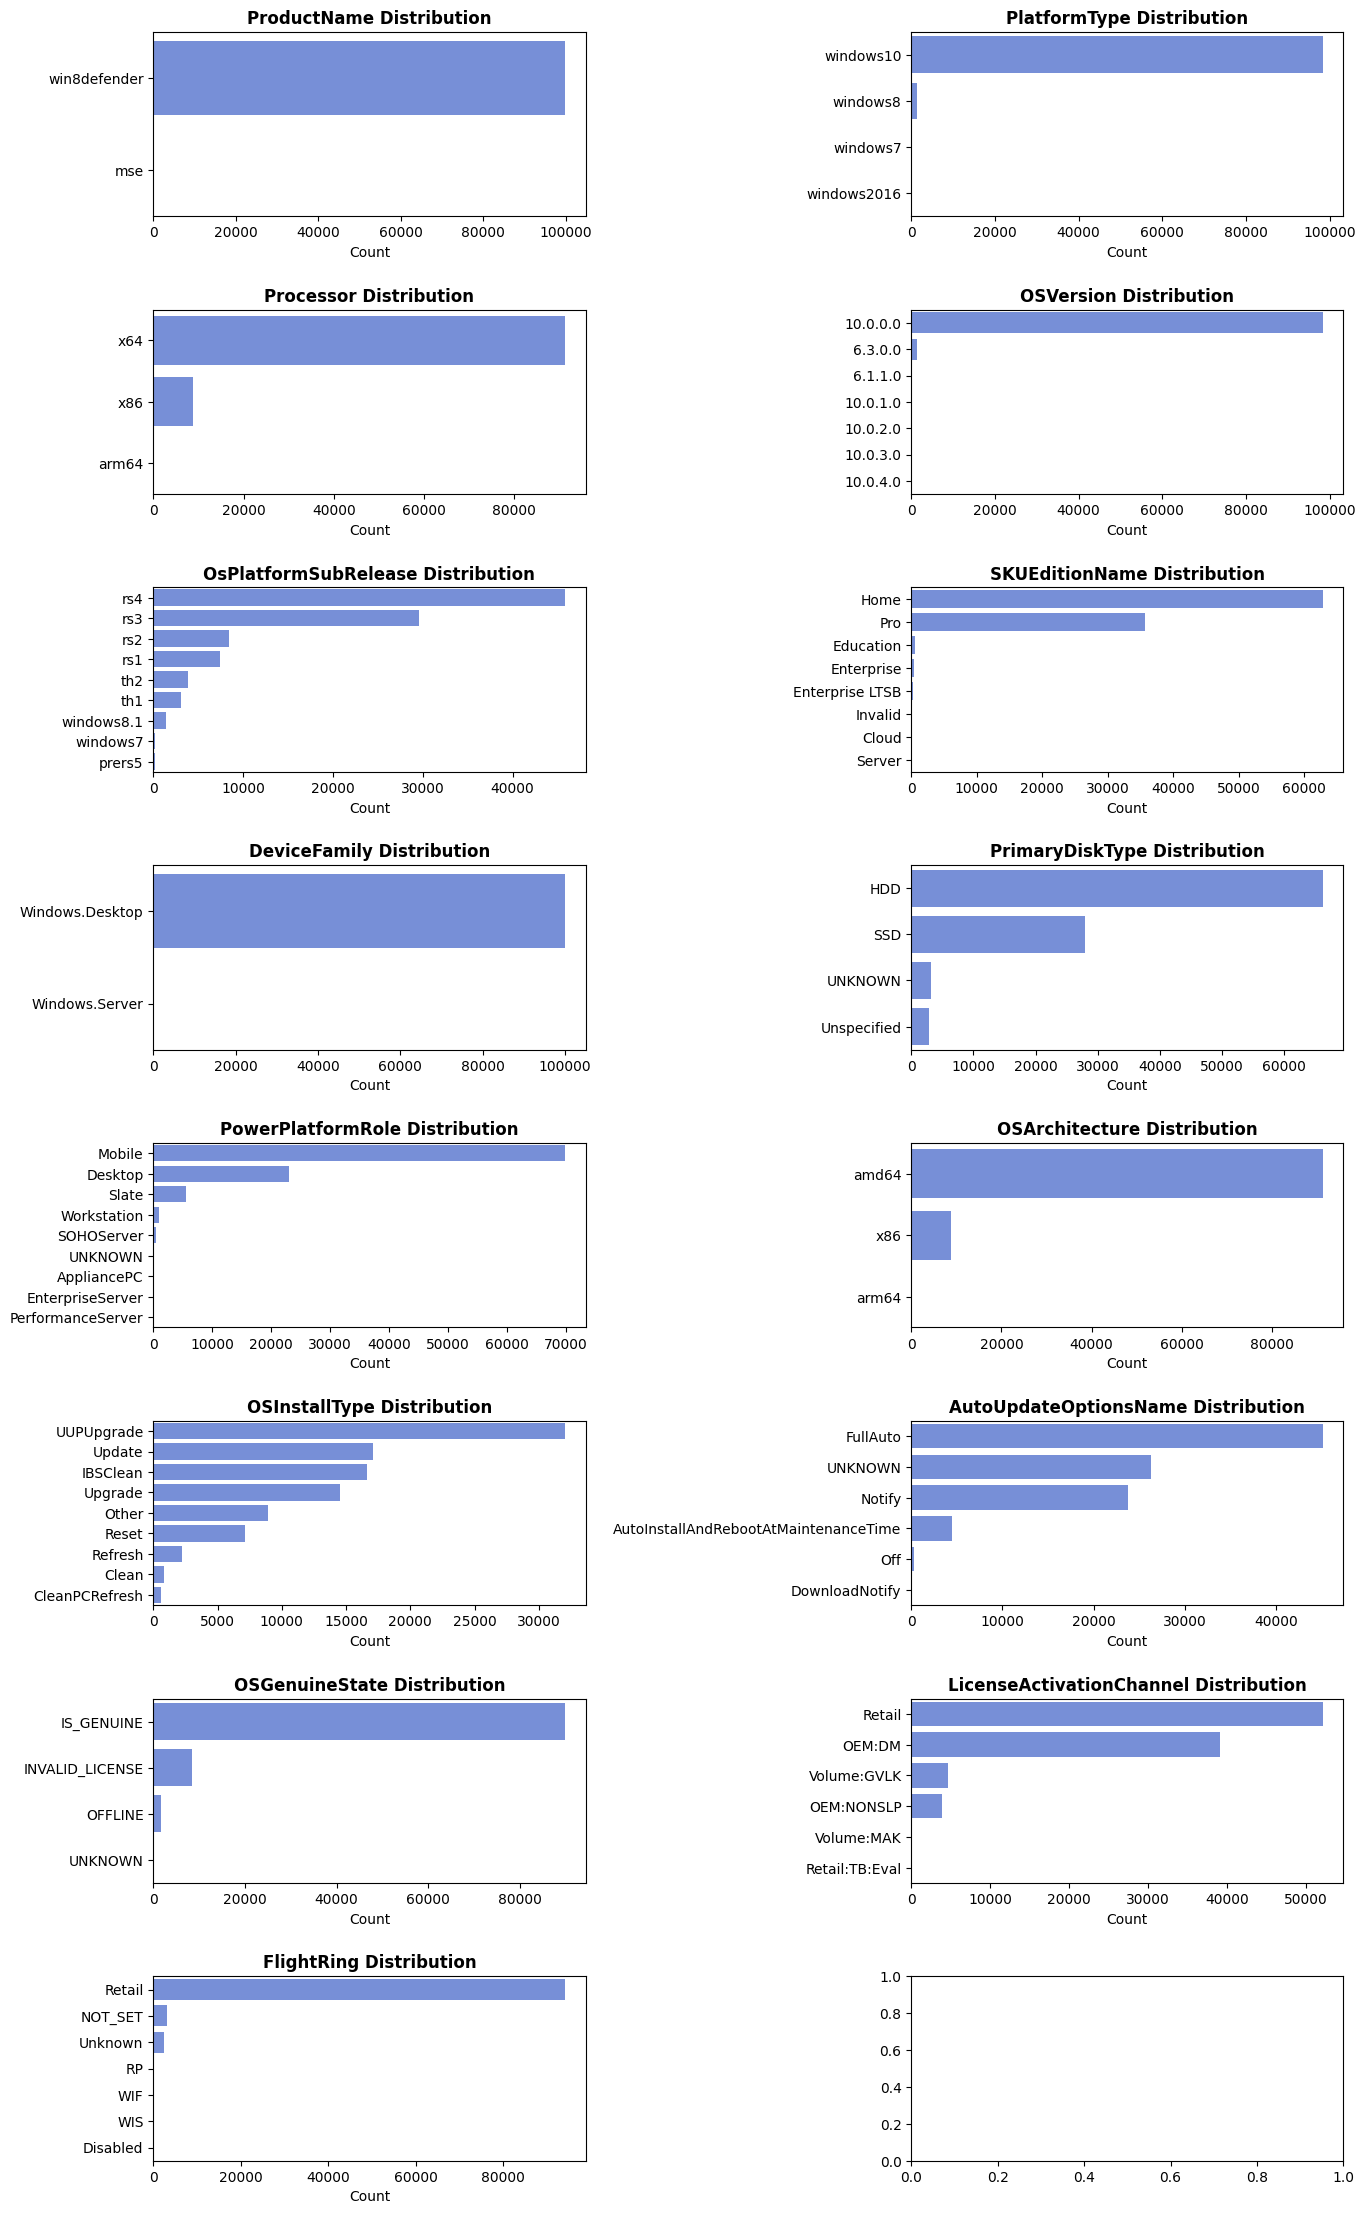

In [ ]:
filtered_features = [col for col in categorical_features if X_train[col].nunique() <= 10]

fig, axes = plt.subplots(len(filtered_features) // 2 + 1, 2, figsize=(14, len(filtered_features) * 1.5))
axes = axes.flatten()

for i, feature in enumerate(filtered_features):
    sns.countplot(y=X_train[feature], ax=axes[i], order=X_train[feature].value_counts().index, color="royalblue", alpha=0.8)
    axes[i].set_title(f"{feature} Distribution", fontweight="bold")
    axes[i].set_xlabel("Count")
    axes[i].set_ylabel("")

fig.tight_layout(pad=2.0)
plt.show()


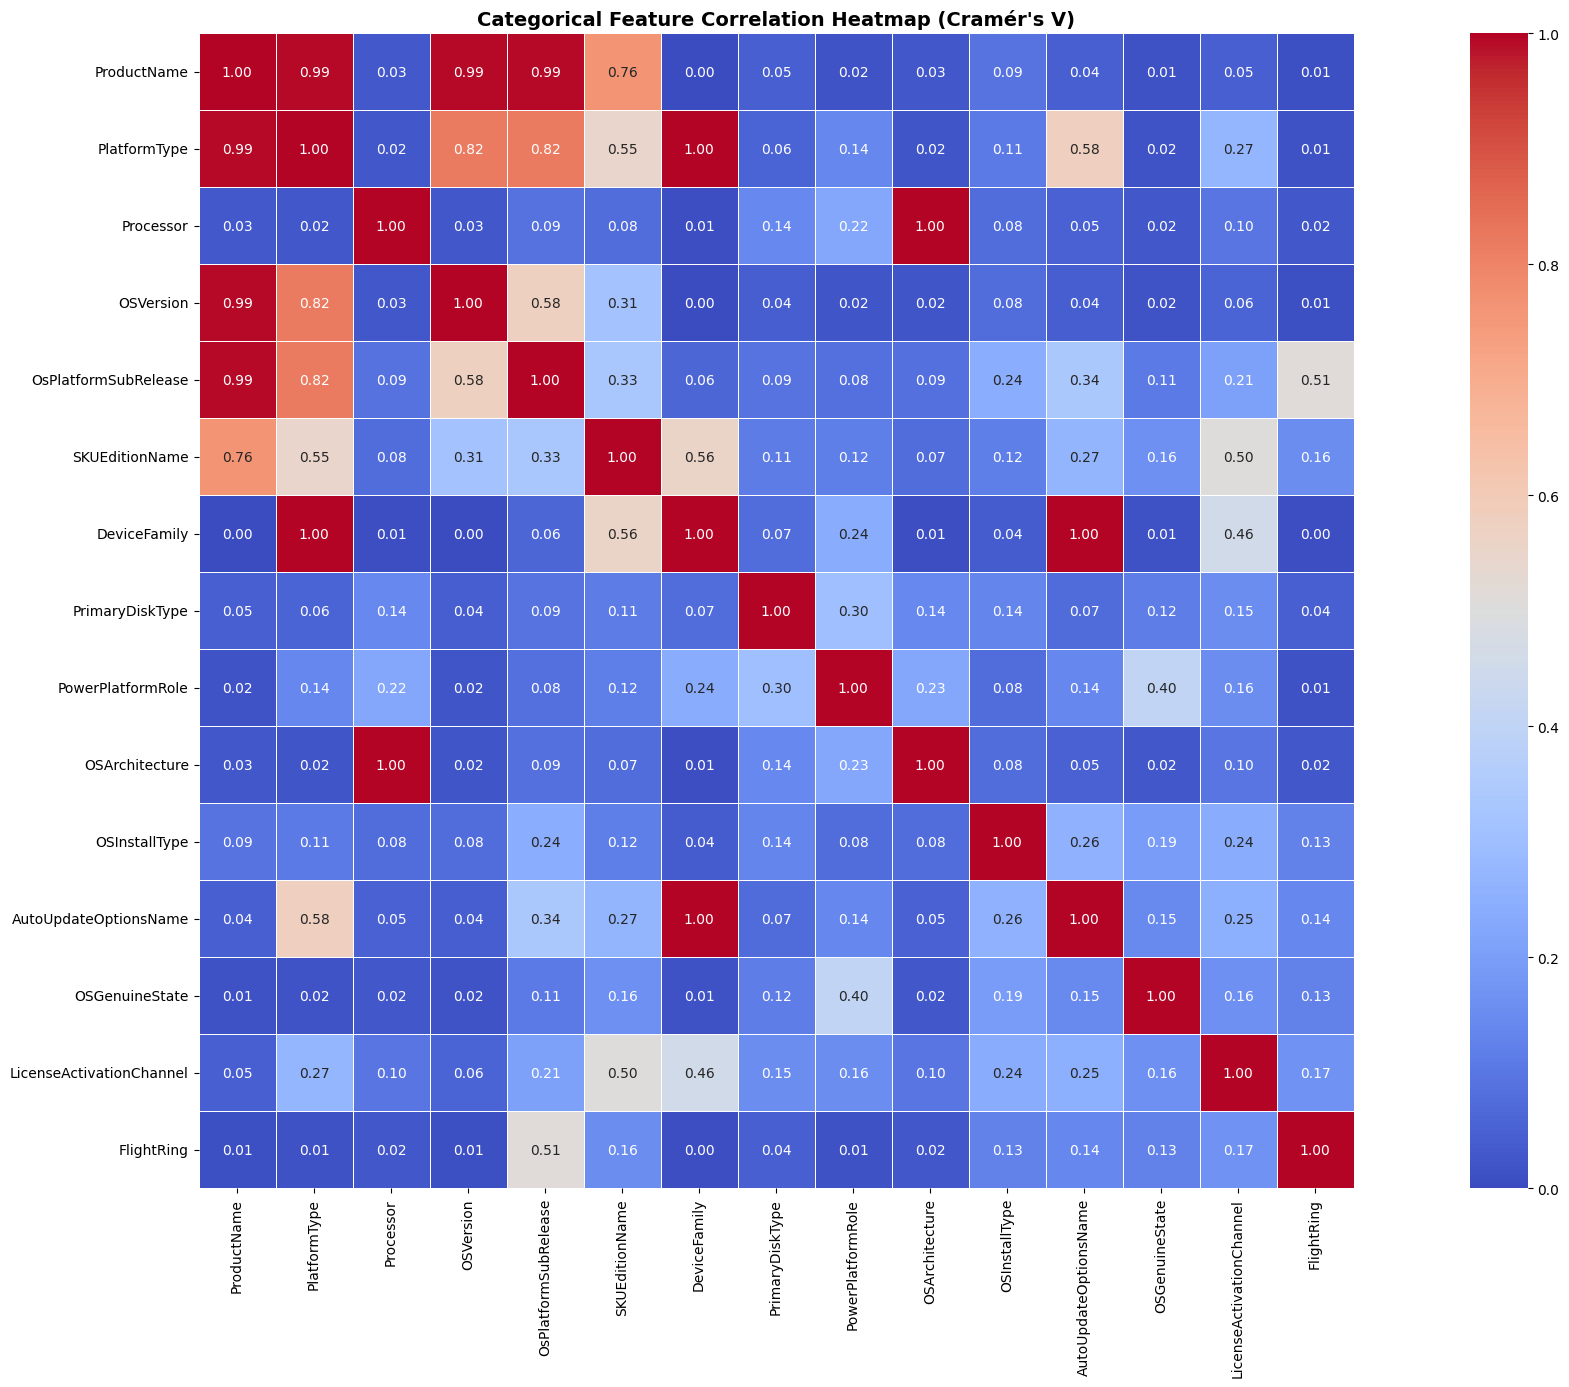

In [ ]:
def cramers_v(x, y):
    contingency_table = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(contingency_table)
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

filtered_features = [col for col in categorical_features if X_train[col].nunique() <= 10]

categorical_corr = pd.DataFrame(index=filtered_features, columns=filtered_features, dtype=float)

for i, col1 in enumerate(filtered_features):
    for j, col2 in enumerate(filtered_features):
        if j >= i:
            if col1 == col2:
                categorical_corr.loc[col1, col2] = 1.0
            else:
                categorical_corr.loc[col1, col2] = cramers_v(X_train[col1], X_train[col2])
                categorical_corr.loc[col2, col1] = categorical_corr.loc[col1, col2]

plt.figure(figsize=(30, 15))
sns.heatmap(categorical_corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5, square=True)
plt.title("Categorical Feature Correlation Heatmap (Cramér's V)", fontsize=14, fontweight="bold")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()


## 6. Target Variable Distribution
This section visualizes the distribution of the target variable using a pie chart. This is crucial for understanding class imbalance, which can affect model training.

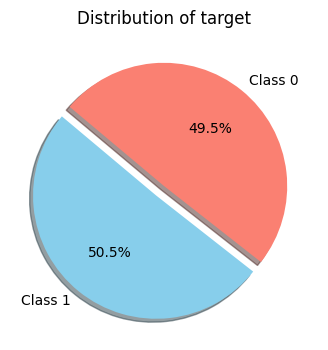

In [ ]:
labels = ['Class 1', 'Class 0']
sizes = y_train.value_counts()
colors = ['skyblue', 'salmon']
explode = (0.1, 0)

plt.figure(figsize=(4,4))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, explode=explode, shadow=True, startangle=140)
plt.title('Distribution of target')
plt.show()



## 7. Feature Selection: Dropping Columns
Based on prior analysis (e.g., high cardinality, irrelevance, redundancy, or domain knowledge), several columns are identified and dropped from both the training and testing datasets to simplify the model and potentially improve performance.

### Rationale for Dropping Columns

The decision to drop specific columns was based on a combination of factors identified during the EDA phase:

*   **High Cardinality / Irrelevance**: Features like `MachineID`, while unique, are identifiers and offer no predictive power in themselves. `OSBuildNumberOnly`, `OSBuildRevisionOnly`, `OSUILocaleID`, `LocaleEnglishNameID`, and `GeoRegionID` often have very high cardinality or are highly correlated with other more meaningful features, making them difficult to encode effectively without creating too many new features or introducing noise.
*   **Constant Values**: `AutoSampleSubmissionEnabled`, `IsBetaUser`, and `IsFlightsDisabled` were found to have almost no variance (e.g., predominantly a single value across the dataset), making them uninformative for prediction.
*   **Redundancy**: `ProductName` and `PlatformType` were often highly correlated with `EngineVersion` or `OSVersion`, and retaining all might introduce unnecessary multicollinearity for some models or increase dimensionality. `HasTpm` was also very constant in our sample.
*   **Domain Knowledge**: In some cases, columns are dropped because they are known to be less relevant from a domain perspective or are highly redundant with other features that capture similar information more effectively.

In [ ]:
drop_cols = ['AutoSampleSubmissionEnabled', 'IsBetaUser', 'IsFlightsDisabled',
             'OSBuildNumberOnly', 'MachineID', 'ProductName', 'PlatformType', 'DeviceFamily',
             'OSUILocaleID', 'OSProductSuite', 'LocaleEnglishNameID', 'OSBuildRevisionOnly',
             'OSBuildNumber', 'HasTpm', 'GeoRegionID', 'CountryID']

X_train_dropped = X_train.drop(columns=drop_cols)
test_dropped = test.drop(columns=drop_cols)


## 8. Feature Engineering
In this section, new features are created and existing ones are transformed to potentially capture more information or improve model performance:
- **`DiffOS`**: Calculated as the difference in days between `DateAS` and `DateOS`, then converted to weeks.
- **`AppVersion`**: The second part of the version string is extracted and converted to an integer.

### Motivation Behind Feature Engineering

Feature engineering is a critical step to extract more predictive power from the raw data. Our two engineered features aim to capture specific aspects:

*   **`DiffOS` (Difference between `DateAS` and `DateOS` in weeks)**: This feature quantifies the time elapsed between the antivirus signature update date (`DateAS`) and the operating system installation date (`DateOS`). A large difference might indicate an older OS installation that has been continuously updated, or a system that hasn't been updated recently. This time-based feature could potentially capture patterns related to system maintenance, vulnerability exposure, or user behavior over time. We convert it to weeks to reduce granularity and potentially capture longer-term trends.

*   **`AppVersion` (Second part of the version string)**: The `AppVersion` originally is a string (e.g., '4.18.1807.18075'). By extracting just the second part (e.g., '18' from '4.18.1807.18075'), we are trying to capture a numerical aspect of the application's version, potentially representing a major revision or update cycle. This conversion allows models to interpret it as an ordinal or numerical feature rather than a complex string, which can simplify encoding and allow the model to learn monotonic relationships if they exist.

In [ ]:
# Feature Engineering 1
X_train_dropped['DiffOS'] = pd.to_datetime(X_train_dropped['DateAS']) - pd.to_datetime(X_train_dropped['DateOS'])
X_train_dropped['DiffOS'] = X_train_dropped['DiffOS'].map(lambda x: x.days//7)
test_dropped['DiffOS'] = pd.to_datetime(test_dropped['DateAS']) - pd.to_datetime(test_dropped['DateOS'])
test_dropped['DiffOS'] = test_dropped['DiffOS'].map(lambda x: x.days//7)

del X_train_dropped['DateAS'], X_train_dropped['DateOS']
del test_dropped['DateAS'], test_dropped['DateOS']

# Feature Engineering 2
X_train_dropped['AppVersion'] = X_train_dropped['AppVersion'].map(lambda x: int(x.split('.')[1]))
test_dropped['AppVersion'] = test_dropped['AppVersion'].map(lambda x: int(x.split('.')[1]))


## 9. Data Preprocessing - Column Definitions
Before applying transformations, columns are categorized into different types based on their characteristics and the preprocessing steps they require:
- **`most_frequent_cols`**: Columns that will be imputed with their most frequent value.
- **`binary_cols`**: Binary categorical columns that will be encoded using BinaryEncoder.
- **`ordinal_cols`**: Ordinal categorical columns that will be encoded using OrdinalEncoder.

In [ ]:
most_frequent_cols = ['SystemVolumeCapacityMB', 'InternalBatteryNumberOfCharges',
    'RealTimeProtectionState', 'AntivirusConfigID', 'NumAntivirusProductsInstalled',
    'NumAntivirusProductsEnabled', 'CityID', 'IEVersionID', 'ProcessorCoreCount',
    'EnableLUA', 'OEMNameID', 'OEMModelID', 'ProcessorManufacturerID', 'PrimaryDiskCapacityMB',
    'ProcessorModelID', 'OSInstallLanguageID', 'FirmwareManufacturerID', 'FirmwareVersionID',
    'RegionIdentifier',  'PrimaryDisplayDiagonalInches', 'PrimaryDisplayResolutionHorizontal',
    'PrimaryDisplayResolutionVertical', 'DiffOS', 'TotalPhysicalRAMMB']


In [ ]:
binary_cols = ['IsPassiveModeEnabled', "IsSystemProtected", "SMode", "FirewallEnabled",
               "HasOpticalDiskDrive", "IsPortableOS", "IsSecureBootEnabled", "IsVirtualDevice",
               "IsTouchEnabled", "IsPenCapable", "IsAlwaysOnAlwaysConnectedCapable", "IsGamer"]


ordinal_cols = ["AppVersion", "SignatureVersion", "OSBuildLab", "MDC2FormFactor", "ChassisType",
               "NumericOSVersion", "OSBranch", "OSEdition", "OSSkuFriendlyName", "FlightRing",
               "OSVersion", "Processor",  "OsPlatformSubRelease", "SKUEditionName", "PrimaryDiskType",
               "PowerPlatformRole", "OSArchitecture", "OSInstallType", "AutoUpdateOptionsName",
               "OSGenuineState", "LicenseActivationChannel", "EngineVersion"]


## 10. Data Preprocessing - ColumnTransformer
This section sets up a `ColumnTransformer` to apply different preprocessing steps to different columns simultaneously. This includes:
- Imputing missing values in `most_frequent_cols` with the most frequent value.
- Applying Binary Encoding to `binary_cols` after imputing missing values.
- Applying Ordinal Encoding to `ordinal_cols` after imputing missing values. `handle_unknown` is set to `use_encoded_value` with `unknown_value=-1` to handle unseen categories during prediction.

In [ ]:
column_transformer = ColumnTransformer(
    transformers=[
        ('most_frequent', SimpleImputer(strategy='most_frequent'), most_frequent_cols),

        ('binary', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('binary', BinaryEncoder())
        ]), binary_cols),

        ('ordinal', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ordinal',  OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
        ]), ordinal_cols),


    ], remainder='passthrough')


column_transformer.fit(X_train_dropped)
X_train_transformed = column_transformer.transform(X_train_dropped)
test_transformed = column_transformer.transform(test_dropped)


## 11. Data Scaling and Splitting
After preprocessing, the data is prepared for model training:
- **Min-Max Scaling**: Numerical features are scaled to a range between 0 and 1 using `MinMaxScaler`. This is important for models sensitive to feature scales.
- **Train-Validation Split**: The training data is split into training and validation sets. This allows for evaluating model performance on unseen data during development. Two sets are created: one scaled (for scale-sensitive models) and one transformed but not scaled (for scale-insensitive models).

In [ ]:
min_max_scaler = MinMaxScaler()

X_train_scaled = min_max_scaler.fit_transform(X_train_transformed)
test_scaled = min_max_scaler.transform(test_transformed)


In [ ]:
# For Scale-Sensitive Models
X_train_scaled, X_val_scaled, y_train_scaled, y_val_scaled = train_test_split(X_train_scaled, y_train, test_size=0.1, random_state=69)

# For Scale-Insensitive Models (for models like LGBM and XGBoost)
X_train_for_lgbm, X_val_for_lgbm, y_train_for_lgbm, y_val_for_lgbm = train_test_split(X_train_transformed, y_train, test_size=0.1, random_state=69)


### Rationale for Scaling and Splitting

Data scaling is crucial for many machine learning algorithms (like K-Nearest Neighbors, SVM, Logistic Regression, and Neural Networks) that are sensitive to the magnitude and scale of features. `MinMaxScaler` transforms features to a common range [0, 1], preventing features with larger values from dominating the learning process.

The data is split into two main sets: one for scale-sensitive models (`X_train_scaled`, `X_val_scaled`) and another (unscaled `X_train_for_lgbm`, `X_val_for_lgbm`) specifically for tree-based models like LightGBM and XGBoost. These tree-based models are generally not sensitive to feature scaling and can sometimes perform better on unscaled, but transformed, data.

In [ ]:
dummy_classifier = DummyClassifier(random_state=69)
dummy_classifier.fit(X_train_scaled, y_train_scaled)

y_pred_dummy = dummy_classifier.predict(X_val_scaled)
dummy_accuracy = accuracy_score(y_val_scaled, y_pred_dummy)

print(f"Dummy Accuracy: {dummy_accuracy:.4f}")


Dummy Accuracy: 0.5110


In [ ]:
knn_classifier = KNeighborsClassifier()
knn_classifier.fit(X_train_scaled, y_train_scaled)

y_pred_knn = knn_classifier.predict(X_val_scaled)
knn_accuracy = accuracy_score(y_val_scaled, y_pred_knn)

print(f"KNN Accuracy: {knn_accuracy:.4f}")


KNN Accuracy: 0.5598


In [ ]:
sgd_classifier = SGDClassifier(random_state=69)
sgd_classifier.fit(X_train_scaled, y_train_scaled)

y_pred_sgd = sgd_classifier.predict(X_val_scaled)
sgd_accuracy = accuracy_score(y_val_scaled, y_pred_sgd)

print(f"SGD Accuracy: {sgd_accuracy:.4f}")


SGD Accuracy: 0.5946


In [ ]:
logistic_regression = LogisticRegression(max_iter=500)
logistic_regression.fit(X_train_scaled, y_train_scaled)

y_pred_logistic = logistic_regression.predict(X_val_scaled)
logistic_accuracy = accuracy_score(y_val_scaled, y_pred_logistic)

print(f"Logistic Regression Accuracy: {logistic_accuracy:.4f}")


Logistic Regression Accuracy: 0.5980


In [ ]:
svm_classifier = SVC()
svm_classifier.fit(X_train_scaled, y_train_scaled)

y_pred_svm = svm_classifier.predict(X_val_scaled)
svm_accuracy = accuracy_score(y_val_scaled, y_pred_svm)

print(f"SVM Accuracy: {svm_accuracy:.4f}")


SVM Accuracy: 0.6013


In [ ]:
mlp_classifier = MLPClassifier(max_iter=500, random_state=1437)
mlp_classifier.fit(X_train_scaled, y_train_scaled)

y_pred_mlp = mlp_classifier.predict(X_val_scaled)
mlp_accuracy = accuracy_score(y_val_scaled, y_pred_mlp)

print(f"MLP Accuracy: {mlp_accuracy:.4f}")


MLP Accuracy: 0.6085


In [ ]:
rfc_classifier = RandomForestClassifier(random_state=69)

rfc_classifier.fit(X_train_scaled, y_train_scaled)

y_pred_rfc = rfc_classifier.predict(X_val_scaled)

rfc_accuracy = accuracy_score(y_val_scaled, y_pred_rfc)

print(f"Random Forest Accuracy: {rfc_accuracy:.4f}")

Random Forest Accuracy: 0.6186


In [ ]:
xgb_classifier = XGBClassifier()

xgb_classifier.fit(X_train_scaled, y_train_scaled)

y_pred_xgb = xgb_classifier.predict(X_val_scaled)

xgb_accuracy = accuracy_score(y_val_scaled, y_pred_xgb)

print(f"XGBoost Accuracy: {xgb_accuracy:.4f}")


XGBoost Accuracy: 0.6251


In [ ]:
xx

NameError: name 'xx' is not defined

In [ ]:
lgbm_classifier = LGBMClassifier(verbose=-1)
lgbm_classifier.fit(X_train_for_lgbm, y_train_for_lgbm)

y_pred_lgbm = lgbm_classifier.predict(X_val_for_lgbm)
lgbm_accuracy = accuracy_score(y_val_for_lgbm, y_pred_lgbm)

print(f"LGBM Accuracy: {lgbm_accuracy:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LGBM Accuracy: 0.6292


/tmp/ipykernel_1772/1472300774.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=np.array(models), y=np.array(accuracies), palette=colors, edgecolor="black", width=0.6)


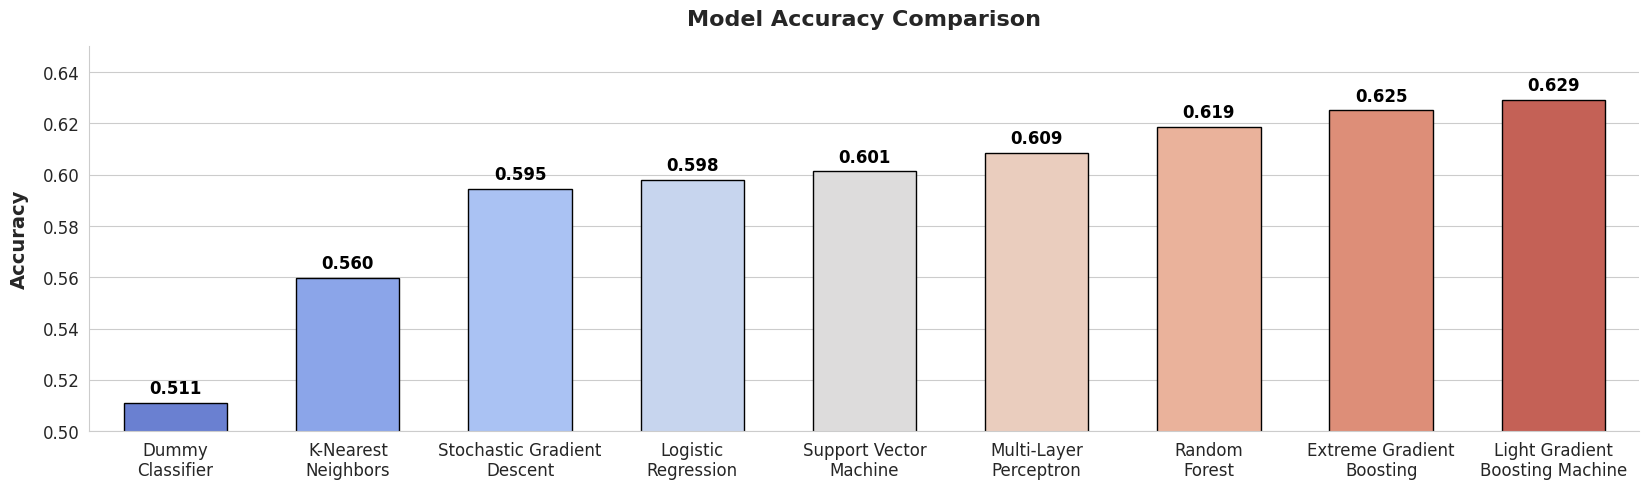

In [ ]:
models = ["Dummy\nClassifier", "K-Nearest\nNeighbors", "Stochastic Gradient\nDescent",
          "Logistic\nRegression", "Support Vector\nMachine", "Multi-Layer\nPerceptron",
          "Random\nForest", "Extreme Gradient\nBoosting", "Light Gradient\nBoosting Machine"]

accuracies = [dummy_accuracy, knn_accuracy, sgd_accuracy, logistic_accuracy, svm_accuracy,
              mlp_accuracy, rfc_accuracy, xgb_accuracy, lgbm_accuracy]


plt.figure(figsize=(20, 5))
sns.set_style("whitegrid")
colors = sns.color_palette("coolwarm", len(models))

# Barplot
ax = sns.barplot(x=np.array(models), y=np.array(accuracies), palette=colors, edgecolor="black", width=0.6)

# Label
for bar, accuracy in zip(ax.patches, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, f"{accuracy:.3f}",
            ha='center', va='bottom', fontsize=12, fontweight="bold", color="black")

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0.50, 0.65)
plt.xlabel("")
plt.ylabel("Accuracy", fontsize=14, fontweight="bold", labelpad=10)
plt.title("Model Accuracy Comparison", fontsize=16, fontweight="bold", pad=15)
sns.despine()
plt.show()



### Initial Model Performance Summary

The bar chart above provides a comparative overview of the initial performance of several baseline classification models. As expected, simple models like `Dummy Classifier` show low accuracy, while more sophisticated models like `XGBoost` and `LGBM` exhibit higher performance. This initial comparison helps identify promising model families for further tuning and ensemble methods.

In [ ]:
print(f"Shape of X_train_transformed: {X_train_transformed.shape}")
print(f"Shape of y_train_transformed: {y_train_transformed.shape}")

Shape of X_train_transformed: (100000, 58)


NameError: name 'y_train_transformed' is not defined

In [ ]:
param_dist = {
    'num_leaves': np.arange(100, 300, 7),
    'max_depth': np.arange(5, 15, 1),
    'learning_rate': np.linspace(0.01, 0.1, 100),
    'n_estimators': np.arange(100, 300),
    'min_child_samples': np.arange(5, 30),
    'min_child_weight': np.logspace(-2, 1, 100),
    'subsample': np.linspace(0.7, 1.0, 100),
    'colsample_bytree': np.linspace(0.7, 1.0, 100),
    'reg_alpha': np.logspace(-3, 0, 100),
    'reg_lambda': np.logspace(-3, 0, 100)
}

lgbm = LGBMClassifier(verbose=-1)

random_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=50,
    scoring='accuracy',
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=69
)

random_search.fit(X_train_for_lgbm, y_train_for_lgbm)
best_lgbm = random_search.best_estimator_
best_lgbm

Fitting 5 folds for each of 50 candidates, totalling 250 fits


LGBMClassifier(colsample_bytree=np.float64(0.7606060606060606),
               learning_rate=np.float64(0.04727272727272728),
               max_depth=np.int64(13), min_child_samples=np.int64(27),
               min_child_weight=np.float64(2.4770763559917115),
               n_estimators=np.int64(246), num_leaves=np.int64(107),
               reg_alpha=np.float64(0.0016297508346206436),
               reg_lambda=np.float64(0.006135907273413176),
               subsample=np.float64(0.7818181818181817), verbose=-1)

### Hyperparameter Tuning with RandomizedSearchCV

To optimize the performance of the `LGBMClassifier`, `RandomizedSearchCV` was employed. This technique efficiently searches a defined hyperparameter space for the best combination of parameters that maximize a given scoring metric (in this case, accuracy) using cross-validation. The output `best_lgbm` shows the optimal hyperparameters found during this search, which are then used to configure the subsequent tuned models.

In [ ]:
# 3 LGBM Models

lgbm1 = LGBMClassifier(
    num_leaves=146,
    max_depth=11,
    learning_rate=0.04059333955483345,
    n_estimators=215,
    min_child_samples=12,
    min_child_weight=5.348307316066151,
    subsample=0.8015824978715238,
    colsample_bytree=0.7528665653163558,
    reg_alpha=0.01794072813847298,
    reg_lambda=0.00446283946806131,
    verbose=-1
)

lgbm2 = LGBMClassifier(
    num_leaves=241,
    max_depth=11,
    learning_rate=0.04267548857660626,
    n_estimators=176,
    min_child_samples=17,
    min_child_weight=0.34453075904087466,
    subsample=0.9420126904183629,
    colsample_bytree=0.8969001870626069,
    reg_alpha=0.2534079006185169,
    reg_lambda=0.22093082929171354,
    verbose=-1
)

lgbm3 = LGBMClassifier(
    num_leaves=227,
    max_depth=10,
    learning_rate=0.02643396947526321,
    n_estimators=247,
    min_child_samples=16,
    min_child_weight=0.3399998175512427,
    subsample=0.9860913792672888,
    colsample_bytree=0.9193166643298747,
    reg_alpha=0.007954215605781124,
    reg_lambda=0.1780820734696766,
    verbose=-1
)

# Train models
lgbm1.fit(X_train_for_lgbm, y_train_for_lgbm)
lgbm2.fit(X_train_for_lgbm, y_train_for_lgbm)
lgbm3.fit(X_train_for_lgbm, y_train_for_lgbm)

# Predictions
y_pred_lgbm1 = lgbm1.predict(X_val_for_lgbm)
y_pred_lgbm2 = lgbm2.predict(X_val_for_lgbm)
y_pred_lgbm3 = lgbm3.predict(X_val_for_lgbm)

# Accuracy
lgbm1_accuracy = accuracy_score(y_val_for_lgbm, y_pred_lgbm1)
lgbm2_accuracy = accuracy_score(y_val_for_lgbm, y_pred_lgbm2)
lgbm3_accuracy = accuracy_score(y_val_for_lgbm, y_pred_lgbm3)

# Results
print(f"Tuned LGBM1 Accuracy: {lgbm1_accuracy:.4f}")
print(f"Tuned LGBM2 Accuracy: {lgbm2_accuracy:.4f}")
print(f"Tuned LGBM3 Accuracy: {lgbm3_accuracy:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Tuned LGBM1 Accuracy: 0.6330
Tuned LGBM2 Accuracy: 0.6307
Tuned LGBM3 Accuracy: 0.6291


### Tuned LightGBM Models Performance (LGBM1, LGBM2, LGBM3)

Following hyperparameter tuning, three distinct `LGBMClassifier` models were configured with different sets of optimized hyperparameters. These models show improved accuracy compared to the initial `LGBM` baseline, indicating the effectiveness of the tuning process. The slight variations in their accuracies highlight the impact of different hyperparameter choices.

In [ ]:
base_models = [
    ('lgbm1', lgbm1),
    ('lgbm2', lgbm2),
    ('lgbm3', lgbm3)
]

voting_classifier = VotingClassifier(
    estimators=base_models,
    voting='hard'
)

# Train
voting_classifier.fit(X_train_for_lgbm, y_train_for_lgbm)

# Predict
y_pred_voting = voting_classifier.predict(X_val_for_lgbm)

# Accuracy
voting_classifier_accuracy = accuracy_score(
    y_val_for_lgbm,
    y_pred_voting
)

print(f"Voting Classifier Accuracy: {voting_classifier_accuracy:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Voting Classifier Accuracy: 0.6316


### Voting Classifier 1 Performance

The first `VotingClassifier` combines the predictions of `lgbm1`, `lgbm2`, and `lgbm3` using a 'hard' voting scheme (majority class prediction). The accuracy of this ensemble is slightly higher than the individual LGBM models, demonstrating the potential benefits of combining diverse models to improve overall robustness and predictive power.

In [ ]:
# 5 More LGBM Models

lgbm4 = LGBMClassifier(
    num_leaves=181,
    max_depth=10,
    learning_rate=0.04130232296795349,
    n_estimators=228,
    min_child_samples=29,
    min_child_weight=1.8974552838538845,
    subsample=0.7827368388408219,
    colsample_bytree=0.7629249518899549,
    reg_alpha=0.07533822749656874,
    reg_lambda=0.0015430279436605976,
    verbose=-1
)

lgbm5 = LGBMClassifier(
    num_leaves=169,
    max_depth=10,
    learning_rate=0.05233350977069071,
    n_estimators=231,
    min_child_samples=22,
    min_child_weight=0.4601062504283119,
    subsample=0.9390809394397799,
    colsample_bytree=0.7764703821961773,
    reg_alpha=0.1598399044304671,
    reg_lambda=1.6612340944171649,
    verbose=-1
)

lgbm6 = LGBMClassifier(
    num_leaves=269,
    max_depth=11,
    learning_rate=0.035393108325162924,
    n_estimators=229,
    min_child_samples=23,
    min_child_weight=0.5340539301261625,
    subsample=0.9246962331578512,
    colsample_bytree=0.9088757439239776,
    reg_alpha=0.2602063481715106,
    reg_lambda=1.0107331287932972,
    verbose=-1
)

lgbm7 = LGBMClassifier(
    num_leaves=186,
    max_depth=11,
    learning_rate=0.04584370337618702,
    n_estimators=151,
    min_child_samples=25,
    min_child_weight=0.1159493172007911,
    subsample=0.5484014391486206,
    colsample_bytree=0.7508636391009044,
    reg_alpha=0.004148047682050917,
    reg_lambda=0.0072449781860701905,
    verbose=-1
)

lgbm8 = LGBMClassifier(
    num_leaves=160,
    max_depth=13,
    learning_rate=0.041619634901885666,
    n_estimators=252,
    min_child_samples=39,
    min_child_weight=0.01163215435201914,
    subsample=0.9461943583274226,
    colsample_bytree=0.7569519218012518,
    reg_alpha=0.003349476296685088,
    reg_lambda=0.1693179077289772,
    verbose=-1
)

# XGBoost Model

xgb = XGBClassifier(
    n_estimators=387,
    max_depth=9,
    learning_rate=0.026577196331014415,
    subsample=0.985994351977102,
    colsample_bytree=0.8102255771398449,
    gamma=1.2078424008928528,
    reg_alpha=0.18482880642623628,
    reg_lambda=0.03203503173352191,
    scale_pos_weight=1.004871302905267
)

# Train models

lgbm4.fit(X_train_for_lgbm, y_train_for_lgbm)
lgbm5.fit(X_train_for_lgbm, y_train_for_lgbm)
lgbm6.fit(X_train_for_lgbm, y_train_for_lgbm)
lgbm7.fit(X_train_for_lgbm, y_train_for_lgbm)
lgbm8.fit(X_train_for_lgbm, y_train_for_lgbm)

xgb.fit(X_train_for_lgbm, y_train_for_lgbm)

# Predictions

y_pred_lgbm4 = lgbm4.predict(X_val_for_lgbm)
y_pred_lgbm5 = lgbm5.predict(X_val_for_lgbm)
y_pred_lgbm6 = lgbm6.predict(X_val_for_lgbm)
y_pred_lgbm7 = lgbm7.predict(X_val_for_lgbm)
y_pred_lgbm8 = lgbm8.predict(X_val_for_lgbm)

y_pred_xgb = xgb.predict(X_val_for_lgbm)

# Accuracy scores

lgbm4_accuracy = accuracy_score(y_val_for_lgbm, y_pred_lgbm4)
lgbm5_accuracy = accuracy_score(y_val_for_lgbm, y_pred_lgbm5)
lgbm6_accuracy = accuracy_score(y_val_for_lgbm, y_pred_lgbm6)
lgbm7_accuracy = accuracy_score(y_val_for_lgbm, y_pred_lgbm7)
lgbm8_accuracy = accuracy_score(y_val_for_lgbm, y_pred_lgbm8)

xgb_accuracy = accuracy_score(y_val_for_lgbm, y_pred_xgb)

# Results

print(f"Tuned LGBM4 Accuracy: {lgbm4_accuracy:.4f}")
print(f"Tuned LGBM5 Accuracy: {lgbm5_accuracy:.4f}")
print(f"Tuned LGBM6 Accuracy: {lgbm6_accuracy:.4f}")
print(f"Tuned LGBM7 Accuracy: {lgbm7_accuracy:.4f}")
print(f"Tuned LGBM8 Accuracy: {lgbm8_accuracy:.4f}")

print(f"Tuned XGB Accuracy: {xgb_accuracy:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Tuned LGBM4 Accuracy: 0.6331
Tuned LGBM5 Accuracy: 0.6327
Tuned LGBM6 Accuracy: 0.6277
Tuned LGBM7 Accuracy: 0.6307
Tuned LGBM8 Accuracy: 0.6324
Tuned XGB Accuracy: 0.6322


### Additional Tuned Models Performance

This section introduces five more tuned `LGBMClassifier` models (`lgbm4` through `lgbm8`) and an optimized `XGBClassifier` model. Each of these models was independently tuned to achieve its best performance. The individual accuracy scores for these models provide further options for ensemble methods, allowing for more diverse combinations in subsequent voting classifiers.

In [ ]:
base_models_2 = [
    ('lgbm8', lgbm8),
    ('lgbm4', lgbm4),
    ('lgbm5', lgbm5),
    ('lgbm6', lgbm6),
    ('lgbm7', lgbm7),
    ('xgb', xgb)
]

voting_classifier_2 = VotingClassifier(
    estimators=base_models_2,
    voting='hard'
)

# Train
voting_classifier_2.fit(X_train_for_lgbm, y_train_for_lgbm)

# Predict
y_pred_vc2 = voting_classifier_2.predict(X_val_for_lgbm)

# Accuracy
voting_classifier_accuracy_2 = accuracy_score(
    y_val_for_lgbm,
    y_pred_vc2
)

print(f"Voting Classifier 2 Accuracy: {voting_classifier_accuracy_2:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Voting Classifier 2 Accuracy: 0.6338


In [ ]:
base_models_3 = [
    ('lgbm8', lgbm8),
    ('lgbm4', lgbm4),
    ('lgbm5', lgbm5),
    ('lgbm2', lgbm2),
    ('lgbm3', lgbm3)
]

voting_classifier_3 = VotingClassifier(
    estimators=base_models_3,
    voting='hard'
)

# Train
voting_classifier_3.fit(X_train_for_lgbm, y_train_for_lgbm)

# Predict
y_pred_vc3 = voting_classifier_3.predict(X_val_for_lgbm)

# Accuracy
voting_classifier_accuracy_3 = accuracy_score(
    y_val_for_lgbm,
    y_pred_vc3
)

print(f"Voting Classifier 3 Accuracy: {voting_classifier_accuracy_3:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Voting Classifier 3 Accuracy: 0.6339


In [ ]:
base_models_4 = [
    ('vc2', voting_classifier_2),
    ('vc3', voting_classifier_3)
]

voting_classifier_4 = VotingClassifier(
    estimators=base_models_4,
    voting='hard'
)

# Train
voting_classifier_4.fit(X_train_for_lgbm, y_train_for_lgbm)

# Predict
y_pred_vc4 = voting_classifier_4.predict(X_val_for_lgbm)

# Accuracy
voting_classifier_accuracy_4 = accuracy_score(
    y_val_for_lgbm,
    y_pred_vc4
)

print(f"Voting Classifier 4 Accuracy: {voting_classifier_accuracy_4:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

Voting Classifier 4 Accuracy: 0.6333


### Ensemble Voting Classifiers Performance

This section showcases three additional `VotingClassifier` ensembles. `Voting Classifier 2` combines a broader set of LGBM models with the tuned XGBoost model. `Voting Classifier 3` selects a different subset of LGBM models. Finally, `Voting Classifier 4` combines the predictions of `Voting Classifier 2` and `Voting Classifier 3`.

The results indicate that `Voting Classifier 3` achieved the highest accuracy among these ensembles, demonstrating that carefully selected combinations of base models can lead to superior performance.

## 12. Model Comparison and Selection

This section consolidates the accuracy scores of all trained models and identifies the best-performing one. A clear comparison helps in choosing the most suitable model for making predictions on the unseen test data.

In [ ]:
all_model_accuracies = {
    "Dummy Classifier": dummy_accuracy,
    "K-Nearest Neighbors": knn_accuracy,
    "Stochastic Gradient Descent": sgd_accuracy,
    "Logistic Regression": logistic_accuracy,
    "Support Vector Machine": svm_accuracy,
    "Multi-Layer Perceptron": mlp_accuracy,
    "Random Forest": rfc_accuracy,
    "XGBoost (initial)": xgb_accuracy,
    "LGBM (initial)": lgbm_accuracy,
    "Tuned LGBM 1": lgbm1_accuracy,
    "Tuned LGBM 2": lgbm2_accuracy,
    "Tuned LGBM 3": lgbm3_accuracy,
    "Voting Classifier (LGBM 1,2,3)": voting_classifier_accuracy,
    "Tuned LGBM 4": lgbm4_accuracy,
    "Tuned LGBM 5": lgbm5_accuracy,
    "Tuned LGBM 6": lgbm6_accuracy,
    "Tuned LGBM 7": lgbm7_accuracy,
    "Tuned LGBM 8": lgbm8_accuracy,
    "Tuned XGBoost": xgb_accuracy, # This refers to the xgb from cell 4sllFgaa309d
    "Voting Classifier 2 (LGBM 8,4,5,6,7 + Tuned XGB)": voting_classifier_accuracy_2,
    "Voting Classifier 3 (LGBM 8,4,5,2,3)": voting_classifier_accuracy_3,
    "Voting Classifier 4 (VC2, VC3)": voting_classifier_accuracy_4
}

accuracy_df = pd.DataFrame(all_model_accuracies.items(), columns=['Model', 'Accuracy']).sort_values(by='Accuracy', ascending=False)
display(accuracy_df)


,Model,Accuracy
20,"Voting Classifier 3 (LGBM 8,4,5,2,3)",0.6339
19,"Voting Classifier 2 (LGBM 8,4,5,6,7 + Tuned XGB)",0.6338
21,"Voting Classifier 4 (VC2, VC3)",0.6333
13,Tuned LGBM 4,0.6331
9,Tuned LGBM 1,0.6330
14,Tuned LGBM 5,0.6327
17,Tuned LGBM 8,0.6324
7,XGBoost (initial),0.6322
18,Tuned XGBoost,0.6322
12,"Voting Classifier (LGBM 1,2,3)",0.6316


From the accuracy comparison, it looks like **Voting Classifier 3** achieved the highest accuracy. Therefore, we will use `voting_classifier_3` to make predictions on the test set.

In [ ]:
# Use the best performing model (Voting Classifier 3) to predict on the test set
final_predictions = voting_classifier_3.predict(test_transformed)

# Create a submission DataFrame
submission = pd.DataFrame({
    'MachineID': test['MachineID'],
    'target': final_predictions
})

# Save the submission file
submission.to_csv('submission.csv', index=False)

print("Submission file created successfully!")
display(submission.head())


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Submission file created successfully!


,MachineID,target
0,c2c61173092ad20db5585ca8c10de6e0,1
1,2e6bb5362ba1ce897feeb1de5edea686,1
2,692649baed1c50bb8d051ae7f06e3625,1
3,2ff95e7d97e9f80ec81c97622dd93ed6,0
4,256766b4c5011e146f05b323863e08a4,0
